# Build an Image Captioning System with OpenRouter

This notebook adapts the original IBM watsonx image captioning lab to use **OpenRouter** with any vision-capable model.

**Table of contents**
- [Introduction](#Introduction)
- [Setup](#Setup)
- [OpenRouter credentials](#OpenRouter-credentials)
- [Image preparation](#Image-preparation)
- [Initialize the model](#Initialize-the-model)
- [Encode the image](#Encode-the-image)
- [Multimodal inference function](#Multimodal-inference-function)
- [Image captioning](#Image-captioning)
- [Object detection](#Object-detection)
- [Conclusion](#Conclusion)
- [Exercises](#Exercises)

## Introduction

Visual content—like photos, screenshots, or charts—often contains important information that can be hard to interpret at a glance. In this guided project, we'll use a multimodal vision model via **OpenRouter** to generate text descriptions and answer questions about images.

OpenRouter provides a unified API (OpenAI-compatible) to access hundreds of models, including vision-capable ones. This notebook uses `python-dotenv` to load credentials from your local `.env` file.

## Setup

Required libraries:
- `openai`: OpenAI-compatible client — works with OpenRouter out of the box.
- `python-dotenv`: loads environment variables from a `.env` file.
- `requests`: downloads images from URLs.
- `Pillow`: optional image display helper.

In [ ]:
# %%capture
# %pip install openai python-dotenv requests Pillow

## OpenRouter credentials

Credentials are loaded from the `.env` file in the project root. Make sure it contains:

```
OPENROUTER_API_KEY=sk-or-v1-...
OPENROUTER_BASE_URL=https://openrouter.ai/api/v1
MODEL_ID=meta-llama/llama-3.2-11b-vision-instruct:free
```

> **Note:** The model must support vision/image inputs. Recommended free options on OpenRouter:
> - `meta-llama/llama-3.2-11b-vision-instruct:free`
> - `google/gemini-2.0-flash-exp:free`
> - `qwen/qwen2-vl-7b-instruct:free`

In [ ]:
import os
from dotenv import load_dotenv

# Load variables from .env (looks up parent directories automatically)
load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.getcwd()), ".env"))

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
OPENROUTER_BASE_URL = os.getenv("OPENROUTER_BASE_URL", "https://openrouter.ai/api/v1")
MODEL_ID_VISION = os.getenv("MODEL_ID_VISION", "nvidia/nemotron-nano-12b-v2-vl:free")

if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY is not set. Check your .env file.")

print(f"Base URL : {OPENROUTER_BASE_URL}")
print(f"Model    : {MODEL_ID_VISION}")
print(f"API Key  : {OPENROUTER_API_KEY[:12]}...")

Base URL : https://snowy-bar-9c48.abdallah-elhidali.workers.dev/api/v1
Model    : nvidia/nemotron-nano-12b-v2-vl:free
API Key  : sk-or-v1-115...


## Image preparation

Download and display the four sample images used throughout this lab.

In [2]:
# url_image_1 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5uo16pKhdB1f2Vz7H8Utkg/image-1.png'
# url_image_2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fsuegY1q_OxKIxNhf6zeYg/image-2.png'
# url_image_3 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/KCh_pM9BVWq_ZdzIBIA9Fw/image-3.png'
# url_image_4 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VaaYLw52RaykwrE3jpFv7g/image-4.png'

# image_urls = [url_image_1, url_image_2, url_image_3, url_image_4]

from pathlib import Path

image_urls = list((Path.cwd() / "data").glob("*.png"))
image_urls

[PosixPath('/home/aelhidal/protos/Build-Multimodal-Generative-AI-Applications/Image-Captioning-System/data/image-2.png'),
 PosixPath('/home/aelhidal/protos/Build-Multimodal-Generative-AI-Applications/Image-Captioning-System/data/image-3.png'),
 PosixPath('/home/aelhidal/protos/Build-Multimodal-Generative-AI-Applications/Image-Captioning-System/data/image-4.png'),
 PosixPath('/home/aelhidal/protos/Build-Multimodal-Generative-AI-Applications/Image-Captioning-System/data/image-1.png')]

Image 1


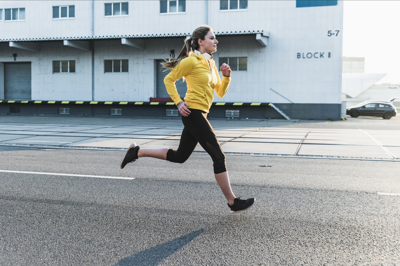

Image 2


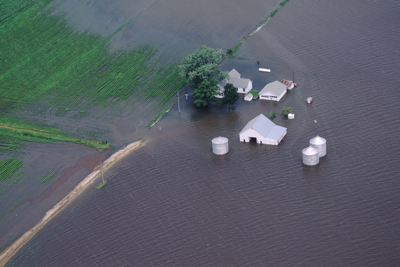

Image 3


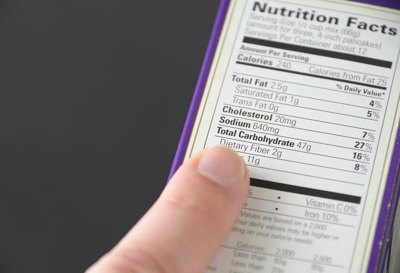

Image 4


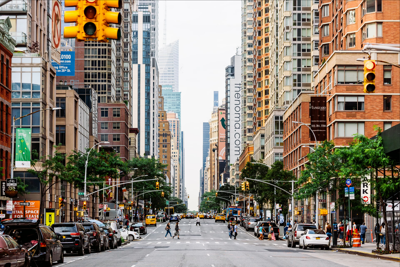

In [3]:
import requests
from IPython.display import display
from PIL import Image
from io import BytesIO

# for i, url in enumerate(image_urls, 1):
#     response = requests.get(url, verify=False)
#     img = Image.open(BytesIO(response.content))
#     img.thumbnail((400, 400))
#     print(f"Image {i}")
#     display(img)



for i, path in enumerate(image_urls, 1):
    img = Image.open(path)
    img.thumbnail((400, 400))
    print(f"Image {i}")
    display(img)

## Initialize the model

Create an OpenAI client pointed at the OpenRouter base URL.

In [4]:
from openai import OpenAI
import httpx

client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url=OPENROUTER_BASE_URL,
    http_client=httpx.Client(verify=False)
)

print("Client initialized successfully.")

Client initialized successfully.


## Encode the image

Images are Base64-encoded so they can be embedded directly in the JSON request body (the OpenAI vision message format).

In [5]:
import base64
from io import BytesIO

def encode_images_to_base64(image_paths, max_size=1024, quality=85):
    """
    Encodes a list of local image files to base64 strings.
    Images are resized to max_size and compressed as JPEG to stay within API limits.

    Parameters:
    - image_paths (list): A list of file paths (Path or str).
    - max_size (int): Maximum width or height in pixels (default 1024).
    - quality (int): JPEG compression quality 1-95 (default 85).

    Returns:
    - list: A list of base64-encoded image strings.
    """
    encoded_images = []
    
    for path in image_paths:
        try:
            img = Image.open(path).convert("RGB")
            img.thumbnail((max_size, max_size), Image.LANCZOS)
            buffer = BytesIO()
            img.save(buffer, format="JPEG", quality=quality)
            encoded_image = base64.b64encode(buffer.getvalue()).decode("utf-8")
            encoded_images.append(encoded_image)
            size_kb = len(buffer.getvalue()) / 50
            name = path.name if hasattr(path, 'name') else path
            print(f"Encoded: {name} → {img.size[0]}x{img.size[1]}px, {size_kb:.1f} KB")
        except Exception as e:
            print(f"Warning: Failed to read {path} ({e})")
            encoded_images.append(None)
    
    return encoded_images

In [6]:
encoded_images = encode_images_to_base64(image_urls)

Encoded: image-2.png → 1024x681px, 3604.4 KB
Encoded: image-3.png → 1024x683px, 2827.7 KB
Encoded: image-4.png → 1024x699px, 1519.7 KB
Encoded: image-1.png → 1024x683px, 5368.6 KB


## Multimodal inference function

The `generate_model_response` function sends a base64-encoded image and a text query to the model using the OpenAI chat completions API (vision format).

**Parameters**
- `encoded_image` (`str`): Base64-encoded image string.
- `user_query` (`str`): The question to ask about the image.
- `system_prompt` (`str`): System-level instruction for the model.
- `temperature` (`float`): Sampling temperature (default `0.2`).

In [7]:
def generate_model_response(
    encoded_image,
    user_query,
    system_prompt="You are a helpful assistant. Answer the following user query in 1 or 2 sentences.",
    temperature=0.2,
):
    """
    Sends an image and a query to the model via OpenRouter and returns the text response.

    Parameters:
    - encoded_image (str): Base64-encoded image string.
    - user_query (str): The user's question about the image.
    - system_prompt (str): System instruction to guide the model's behaviour.
    - temperature (float): Sampling temperature.

    Returns:
    - str: The model's response.
    """
    response = client.chat.completions.create(
        model=MODEL_ID_VISION,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": user_query},
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{encoded_image}"
                        },
                    },
                ],
            },
        ],
    )
    return response.choices[0].message.content

## Image captioning

Loop through all four images and ask the model to describe each one.

In [ ]:
user_query = "Describe the photo"



for i, image in enumerate(encoded_images[:1]):
    response = generate_model_response(image, user_query)
    print(f"Description for image {i + 1}:\n{response}\n")

Description for image 1:
The image captures a woman jogging on an empty road, wearing a bright yellow hoodie, black leggings, and black sneakers, with her hair tied back in a ponytail and a smile on her face. She runs past a white industrial building labeled "BLOCK II" and "5-7," with a parked car and a yellow-and-black striped barrier visible in the background under a clear sky, suggesting an early morning or late afternoon setting.




## Object detection

Image 3


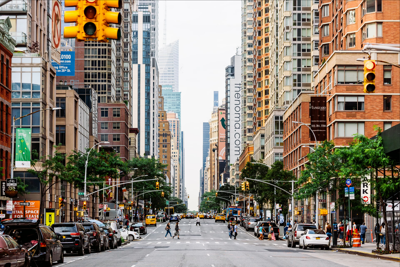

User Query : How many cars are in this image?
Model Response: 15



In [14]:



# Image 2 — woman running outdoors
idx = 3
image = encoded_images[idx]
user_query = "How many cars are in this image?"

img = Image.open(image_urls[idx])
img.thumbnail((400, 400))
print(f"Image {idx}")
display(img)

print("User Query :", user_query)
print("Model Response:", generate_model_response(image, user_query))

Image 1


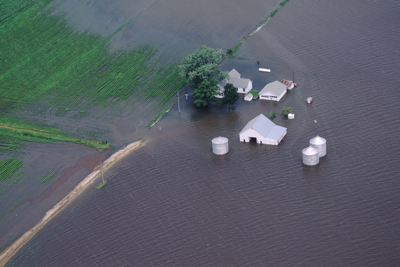

User Query : How severe is the damage in this image?
Model Response: The damage in the image appears to be severe, as extensive flooding has submerged multiple structures (houses, barns) and large areas of land, indicating significant impact on property and the environment. Thus, the severity is Severe.



In [16]:
# Image 3 — flooding / damage scene
idx = 1
image = encoded_images[idx]
user_query = "How severe is the damage in this image?"

img = Image.open(image_urls[idx])
img.thumbnail((400, 400))
print(f"Image {idx}")
display(img)

print("User Query :", user_query)
print("Model Response:", generate_model_response(image, user_query))

Image 2


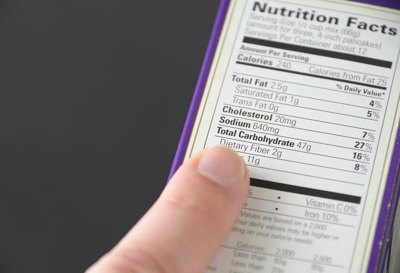

User Query : How much sodium is in this product?
Model Response: The product contains 640mg of sodium per serving.



In [19]:
# Image 4 — nutrition label
idx = 2
image = encoded_images[idx]
user_query = "How much sodium is in this product?"

img = Image.open(image_urls[idx])
img.thumbnail((400, 400))
print(f"Image {idx}")
display(img)

print("User Query :", user_query)
print("Model Response:", generate_model_response(image, user_query))

## Conclusion

In this notebook you replaced the IBM watsonx dependency with **OpenRouter**, keeping the same multimodal workflow:

- Credentials loaded from `.env` via `python-dotenv`.
- OpenAI-compatible client pointed at the OpenRouter base URL.
- Base64 image encoding embedded in the `image_url` message field.
- Any vision-capable model available on OpenRouter can be swapped in by changing `MODEL_ID` in `.env`.

## Exercises

**Exercise 1** — Ask "How much cholesterol is in this product?" using image 4.

In [ ]:
# Write your code here

<details>
    <summary>Click here for Solution</summary>

```python
image = encoded_images[3]
user_query = "How much cholesterol is in this product?"
print("User Query :", user_query)
print("Model Response:", generate_model_response(image, user_query))
```
</details>

**Exercise 2** — Ask "What is the color of the woman's jacket?" using image 2.

In [ ]:
# Write your code here

<details>
    <summary>Click here for Solution</summary>

```python
image = encoded_images[1]
user_query = "What is the color of the woman's jacket?"
print("User Query :", user_query)
print("Model Response:", generate_model_response(image, user_query))
```
</details>